#  DATA ANALYTICS USIND LLMS -VOIS INTERNSHIP
###  VOIS INTERNSHIP-MAJOR PROJECT
#### Author :  REENA SHARON Y
#### Created on : 16-11-24
#### Dataset: DoctorVisits-DA
#### About Dataset: 
##### 1. This Dataset is a CSV file that contains sales data from a company called "Super Store". 
##### 2. It includes information about each order, such as the shipping method, customer segment, location, product category and sub-category, sales amount, quantity, discount, and profit.
##### 3. It consist of information about the number of visits, gender, age, income obtained by each individual, illness, reduce in activity due to illness, health, private, freepoor, freerepat, nchronic, lchronic
##### 4. This data is used to find the number of duplicates,count of illness,count of illness based on gender,analyzes of income, reduced activity by individual due to illness,
##### missing values,visualize the correlation between each attribute using heatmap,finding the correlation between income and no. of visits,gender wise illnes,insurance analysis,health status vs activity reduction  heatmap ,Reduced activity by gender bar plot.
##### 5. This data frame containing 5,190 observations on 12 variables.

#### Student Details:
##### NAME           :REENA SHARON Y
##### COLLEGE        :PANIMALAR ENGINEERING COLLEGE
##### YEAR           :III
##### BRANCH         :ARTIFICIAL INTELLIGENCE AND DATA SCIENCE


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Read the dataset
df = pd.read_csv('E:/vscode/vois/DoctorVisits-DA.csv')

# Check duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Count of illness
illness_counts = df['illness'].value_counts().sort_index()
print("\nNumber of people based on illness count:")
print(illness_counts)

# Gender wise illness
gender_illness = pd.crosstab(df['gender'], df['illness'])
print("\nGender wise illness distribution:")
print(gender_illness)

Number of duplicate rows: 0

Number of people based on illness count:
illness
0    1554
1    1638
2     946
3     542
4     274
5     236
Name: count, dtype: int64

Gender wise illness distribution:
illness    0    1    2    3    4    5
gender                               
female   679  834  531  333  167  158
male     875  804  415  209  107   78


In [3]:
# Income analysis
print("Income Statistics:")
print(df['income'].describe())

Income Statistics:
count    5190.000000
mean        0.583160
std         0.368907
min         0.000000
25%         0.250000
50%         0.550000
75%         0.900000
max         1.500000
Name: income, dtype: float64


In [ ]:
# Reduced activity by gender
reduced_by_gender = df.groupby('gender')['reduced'].mean()
print("\nAverage reduced activity days by gender:")
print(reduced_by_gender)


Average reduced activity days by gender:
gender
female    0.975574
male      0.738344
Name: reduced, dtype: float64


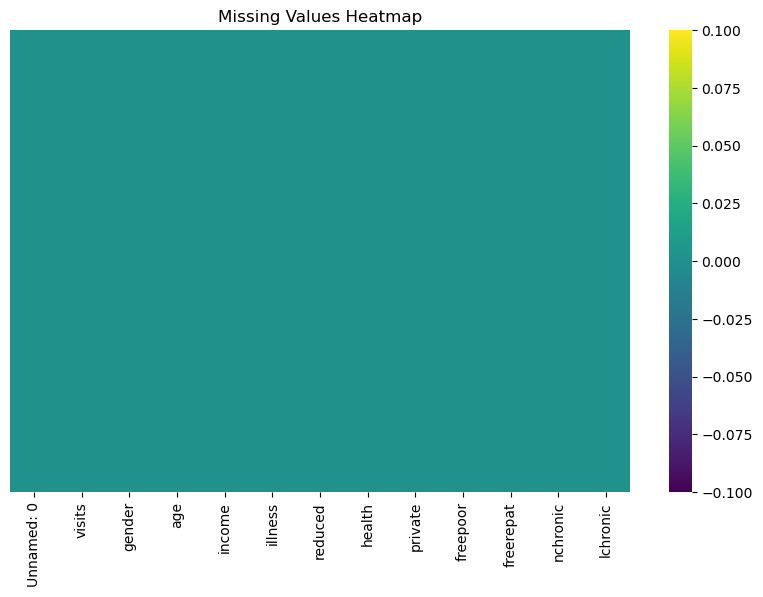

In [ ]:
# Missing values heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

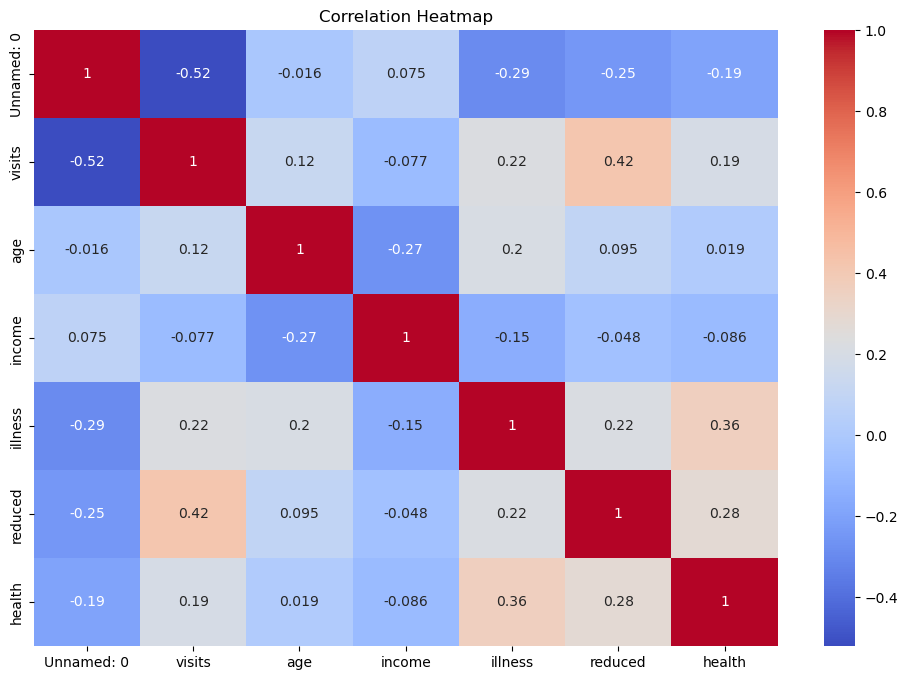

In [6]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

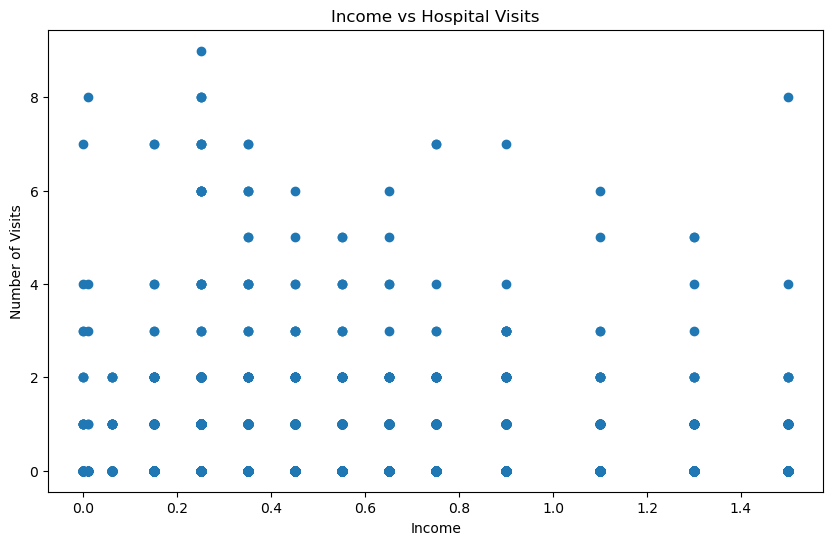

In [7]:
# Income vs Visits scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['income'], df['visits'])
plt.xlabel('Income')
plt.ylabel('Number of Visits')
plt.title('Income vs Hospital Visits')
plt.show()

<Figure size 1000x600 with 0 Axes>

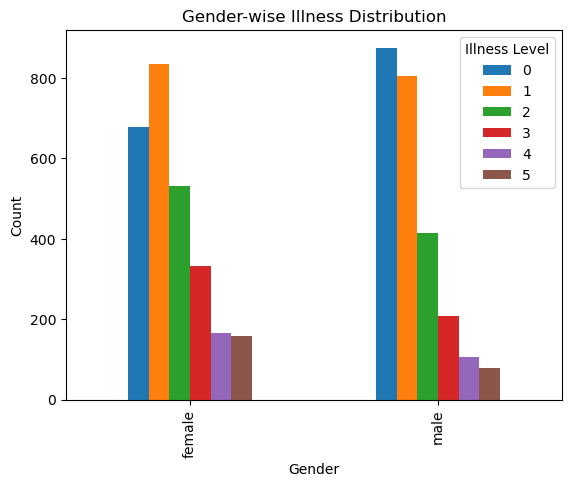

In [8]:
# Gender-wise illness count
plt.figure(figsize=(10, 6))
gender_illness = df.groupby(['gender', 'illness']).size().unstack()
gender_illness.plot(kind='bar')
plt.title('Gender-wise Illness Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Illness Level')
plt.show()

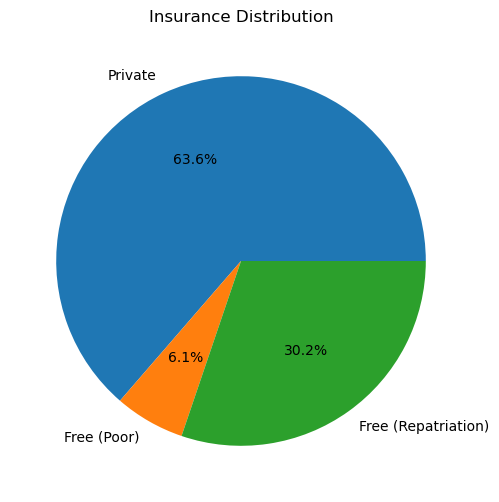

In [9]:
# Insurance analysis
insurance_data = {
    'Private': (df['private'] == 'yes').mean() * 100,
    'Free (Poor)': (df['freepoor'] == 'yes').mean() * 100,
    'Free (Repatriation)': (df['freerepat'] == 'yes').mean() * 100
}
plt.figure(figsize=(8, 6))
plt.pie(insurance_data.values(), labels=insurance_data.keys(), autopct='%1.1f%%')
plt.title('Insurance Distribution')
plt.show()

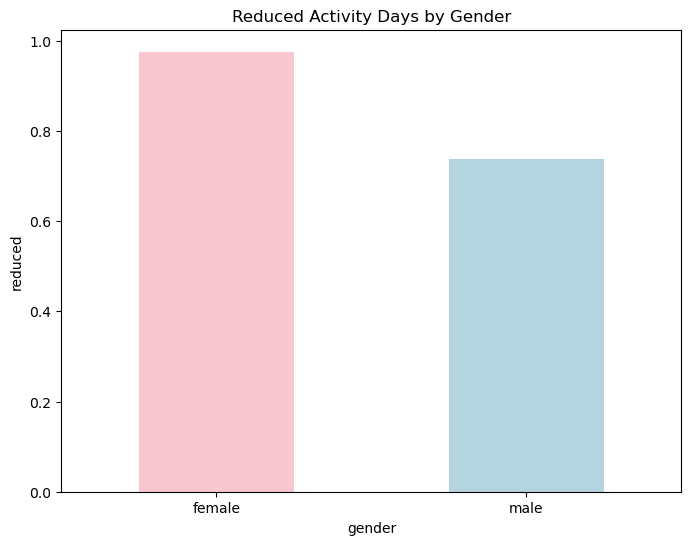

In [36]:
# Reduced activity by gender bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='gender', y='reduced', data=df,hue='gender', width=0.5 ,palette=["pink","lightblue"],errorbar=None)
plt.title('Reduced Activity Days by Gender')
plt.show()

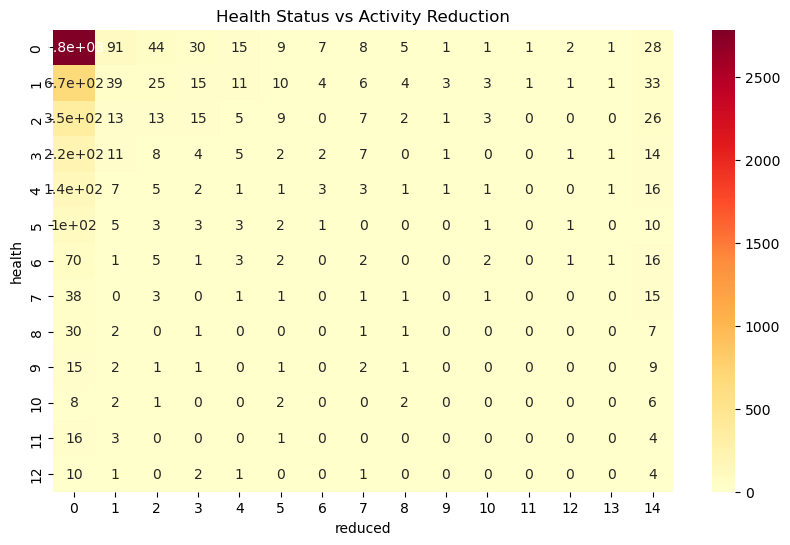

In [11]:
# Health status vs Activity reduction heatmap
plt.figure(figsize=(10, 6))
health_reduced = pd.crosstab(df['health'], df['reduced'])
sns.heatmap(health_reduced, annot=True, cmap='YlOrRd')
plt.title('Health Status vs Activity Reduction')
plt.show()